# Counterfactual Explanations Tutorial - Part 1

Welcome to the first part of our counterfactual explanations tutorial! In this notebook, we'll explore the **Wachter et al. (2017)** approach to generating counterfactual explanations.

## What are Counterfactual Explanations?

Counterfactual explanations answer the question: *"What would need to change in the input for the model to produce a different prediction?"*

For example, if a loan application is rejected, a counterfactual explanation might tell us: *"If your income were $5,000 higher and you had 2 fewer credit inquiries, your loan would be approved."*


In [1]:
# Import necessary libraries
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## The Wachter et al. (2017) Formulation

The paper [*Counterfactual Explanations without Opening the Black Box*](https://arxiv.org/pdf/1711.00399) by Wachter *et al.* introduced an optimization-based approach to generate counterfactual explanations.

### Key Idea

Given:
- An input instance **$x$** with prediction **$f(x)$**  
- A desired target prediction **$y'$** (different from $f(x)$)  

Find the **closest** instance **$x'$** such that **$f(x') = y'$**

### The Optimization Problem

The authors formulate this as a constrained optimization problem:

$$
\begin{aligned}
\min_{x'} \quad & ||x' - x||_2^2 \\
\text{s.t.} \quad & f(x') = y'
\end{aligned}
$$

## Reformulation as Unconstrained Optimization

To solve this optimization problem using gradient-based methods, we reformulate the constrained problem as an **unconstrained optimization** problem using a loss function:

### The Loss Function

$$L(x') = \lambda_1 \cdot d(x, x') + \lambda_2 \cdot \ell(f(x'), y')$$

Where:
- **$d(x, x')$**: Distance function (typically L2 distance: $||x' - x||_2^2$)  
- **$\ell(f(x'), y')$**: Loss function measuring how far $f(x')$ is from the target $y'$  
- **$\lambda_1, \lambda_2$**: Hyperparameters balancing proximity vs. prediction change  

### Distance Component

The distance component encourages the counterfactual to be close to the original:

$$d(x, x') = ||x' - x||_2^2 = \sum_{i=1}^{d} (x'_i - x_i)^2$$

### Prediction Loss Component

For binary classification with target class $y'$, we can use:

$$\ell(f(x'), y') = \max(0.5 + \tau - f(x'), 0)$$

Where:
- **$\tau$**: Margin parameter (e.g., 0.1)
- **$f(x')$**: Model's probability output for class 1

This loss is 0 when the model confidently predicts the target class, and increases as the prediction moves away from the target.

### Alternative: Cross-Entropy Loss

We can also use standard cross-entropy loss:

$$\ell(f(x'), y') = -y' \log(f(x')) - (1-y') \log(1-f(x'))$$

### Gradient-Based Optimization

Since both components are differentiable, we can use gradient descent to minimize L(x'):

$$x'^{(t+1)} = x'^{(t)} - \alpha \nabla_{x'} L(x'^{(t)})$$

Where α is the learning rate.


## Dataset: Two Moons

We'll use the classic "two moons" dataset for our demonstration. This is a 2D binary classification problem where the data forms two interleaving half-circles, making it perfect for visualizing counterfactual explanations.


In [2]:
from counterfactuals.datasets.file_dataset import FileDataset
from counterfactuals.datasets.preprocess_datasets.preprocess_moons import (
    transform_moons,
)


dataset = FileDataset(config_path="../config/datasets/moons.yaml")
dataset.X_train, dataset.X_test, dataset.y_train, dataset.y_test = transform_moons(
    dataset.X_train, dataset.X_test, dataset.y_train, dataset.y_test
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(dataset.X_train)
X_test_scaled = scaler.transform(dataset.X_test)

dataset.X_train, dataset.X_test = X_train_scaled, X_test_scaled

train_dataset = TensorDataset(
    torch.tensor(dataset.X_train, dtype=torch.float32),
    torch.tensor(dataset.y_train, dtype=torch.float32),
)
test_dataset = TensorDataset(
    torch.tensor(dataset.X_test, dtype=torch.float32),
    torch.tensor(dataset.y_test, dtype=torch.float32),
)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

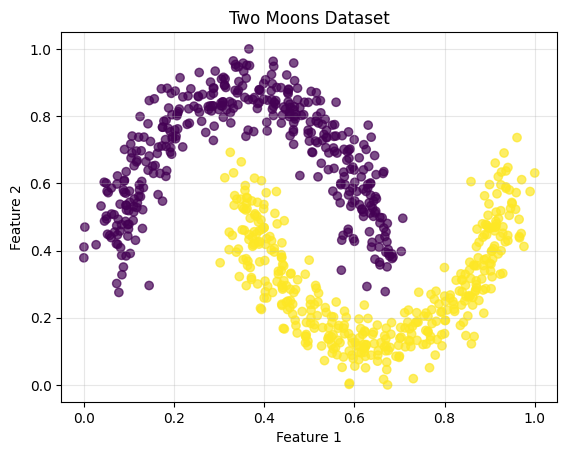

In [3]:
# Visualize the dataset
plt.figure()
scatter = plt.scatter(
    dataset.X_train[:, 0],
    dataset.X_train[:, 1],
    c=dataset.y_train,
    cmap="viridis",
    alpha=0.7,
)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

## Neural Network Model

We'll create a simple feedforward neural network for binary classification. The model should be complex enough to learn the moons pattern but simple enough for clear counterfactual explanations.


In [4]:
from counterfactuals.models.classifier.multilayer_perceptron import MLPClassifier


discriminative_model = MLPClassifier(2, 2, [128, 128, 128], dropout=0.0)

## Model Training


In [5]:
discriminative_model.fit(
    train_dataloader, test_dataloader, epochs=10000, patience=1000, lr=0.001
)

Epoch 1094, Train: 0.0000, test: 0.0000, patience: 1000:  11%|█         | 1095/10000 [00:24<03:17, 45.17it/s]


/Users/lukasz/Desktop/ML-in-PL-counterfactuals/.venv/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


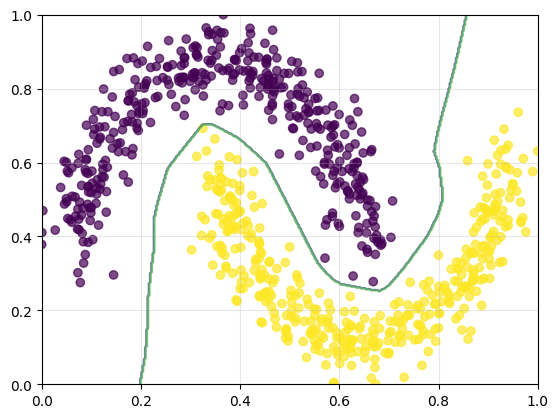

In [6]:
from counterfactuals.plotting.plot_utils import plot_classifier_decision_region

fig, ax = plt.subplots(1, 1)
ax.scatter(
    dataset.X_train[:, 0],
    dataset.X_train[:, 1],
    c=dataset.y_train,
    cmap="viridis",
    alpha=0.7,
)
ax.grid(True, alpha=0.3)
plot_classifier_decision_region(ax, discriminative_model)
plt.show()

---

# 🚀 **YOUR TURN: Implement Counterfactual Generation**

## Task Overview

Your goal is to implement a `CounterfactualGenerator` class that:

1. **Takes an input instance** and finds the closest counterfactual explanation
2. **Uses gradient-based optimization** to minimize the loss function: `L(x') = λ₁ * d(x, x') + λ₂ * ℓ(f(x'), y')`
3. **Returns the counterfactual instance** that changes the model's prediction

## Implementation Guidelines

### Class Structure
```python
class CounterfactualGenerator:
    def __init__(self):
        # Initialize your counterfactual generator
        pass
    
    def generate(self):
        # Generate counterfactual explanation for x_orig
        # Returns: counterfactual instance, success flag, iterations used
        pass
```

### Key Components to Implement

1. **Distance Function**: Implement L2 distance `d(x, x')`
2. **Prediction Loss**: Choose between margin loss or cross-entropy loss
3. **Gradient Optimization**: Use PyTorch's autograd for gradient computation
4. **Stopping Criteria**: Stop when target prediction is achieved or max iterations reached

### Hints

- Initialize `x'` as a copy of the original input `x`
- Freeze model weights
- Make `x'` a PyTorch tensor with `requires_grad=True`
- Use `torch.optim.Adam` or `torch.optim.SGD` for optimization
- Track the loss components separately for debugging

## Your Implementation Space

👇 **Write your code in the cells below** 👇


In [ ]:
import torch
import torch.nn.functional as F


class CounterfactualGenerator:
    def __init__(
        self,
        model,
        lambda1=1.0,
        lambda2=1.0,
        lr=0.01,
        max_iterations=10000,
    ):
        """
        Initialize the counterfactual generator

        Args:
            model: Trained PyTorch model (expects a tensor input and returns logits or a single logit)
            lambda1: Weight for distance loss (L2)
            lambda2: Weight for prediction loss
            lr: Learning rate for optimization
            max_iterations: Maximum number of optimization steps
        """
        self.model = model
        self.lambda1 = float(lambda1)
        self.lambda2 = float(lambda2)
        self.lr = float(lr)
        self.max_iterations = int(max_iterations)
        for p in self.model.parameters():
            p.requires_grad_(False)
        self.model.eval()
        self.loss_func = self.cross_entropy_loss

    def distance_loss(self, x_orig, x_cf):
        """
        Compute L2 distance between original and counterfactual

        Args:
            x_orig: Original input (tensor)
            x_cf: Counterfactual input (tensor)
        Returns:
            Scalar L2 distance loss
        """
        return ((x_cf - x_orig) ** 2).mean()

    def cross_entropy_loss(self, x_cf, target_class):
        """
        Compute prediction loss (how far is the prediction from target)

        Args:
            x_cf: Counterfactual input (tensor)
            target_class: Desired target class (int)
        Returns:
            Scalar prediction loss
        """
        logits = self.model(x_cf)
        if logits.dim() == 1:
            logits = logits.unsqueeze(0)

        y = torch.full(
            (logits.shape[0],),
            int(target_class),
            dtype=torch.long,
        )
        loss = F.cross_entropy(logits, y)
        return loss

    def generate(self, x_orig, target_class):
        """
        Generate counterfactual explanation

        Args:
            x_orig: Original input instance (tensor: shape (D,) or (1,D,...) etc.)
            target_class: Desired target class (0 or 1 for binary; int for multi-class)
            tolerance: Stop when P(target_class) >= 1 - tolerance (e.g., 0.9 by default)

        Returns:
            counterfactual: Generated counterfactual instance (tensor, same shape as x_orig)
            success: Whether counterfactual was successfully found (bool)
            iterations: Number of optimization iterations used (int)
        """
        x_cf = x_orig.clone().detach().requires_grad_(True)
        optimizer = torch.optim.Adam([x_cf], lr=self.lr)

        for it in range(1, self.max_iterations + 1):
            optimizer.zero_grad()
            d_loss = self.distance_loss(x_orig, x_cf)
            p_loss = self.loss_func(x_cf, target_class)
            loss = self.lambda1 * d_loss + self.lambda2 * p_loss

            loss.backward()
            optimizer.step()

        x_cf_out = x_cf.detach()
        return x_cf_out

In [8]:
cf_generator = CounterfactualGenerator(discriminative_model)
X_test_orig = dataset.X_test[dataset.y_test == 0]
y_test_origin = dataset.y_test[dataset.y_test == 0]
X_test_orig = torch.tensor(X_test_orig)
X_test_cfs = cf_generator.generate(X_test_orig, 1)

/Users/lukasz/Desktop/ML-in-PL-counterfactuals/.venv/lib/python3.12/site-packages/counterfactuals/plotting/counterfactual_visualization.py:34: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/lukasz/Desktop/ML-in-PL-counterfactuals/.venv/lib/python3.12/site-packages/counterfactuals/plotting/counterfactual_visualization.py:42: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


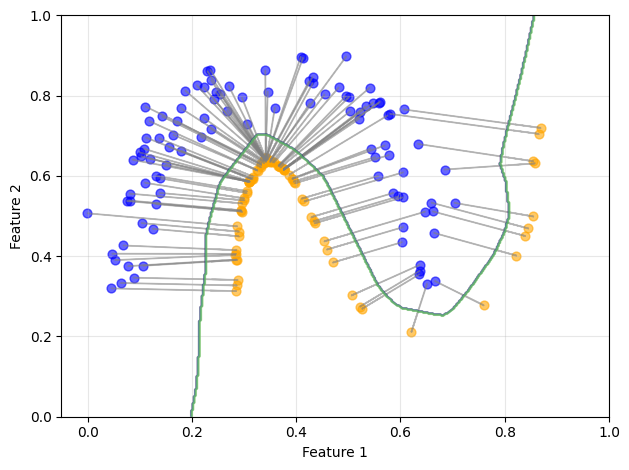

In [9]:
from counterfactuals.plotting.counterfactual_visualization import plot_counterfactuals

plot_counterfactuals(X_test_orig, X_test_cfs, 0.5, discriminative_model)

In [10]:
from counterfactuals.metrics.orchestrator import MetricsOrchestrator

generative_model = None
y_target = np.abs(1 - y_test_origin)

metrics_cf = MetricsOrchestrator(
    disc_model=discriminative_model,
    gen_model=generative_model,
    X_cf=X_test_cfs,
    X_train=dataset.X_train,
    y_train=dataset.y_train,
    X_test=X_test_orig,
    y_test=y_test_origin,
    y_target=y_target,
    continuous_features=[0, 1],
    categorical_features=[],
    ratio_cont=None,
    prob_plausibility_threshold=0,
    metrics_conf_path="../config/metrics/default.yaml",
)
metrics = metrics_cf.calculate_all_metrics()

In [11]:
metrics

{'coverage': 1.0,
 'validity': 1.0,
 'actionability': 0.0,
 'sparsity': 1.0,
 'proximity_categorical_hamming': 0.1990356657571279,
 'proximity_categorical_jaccard': 0.1990356657571279,
 'proximity_continuous_manhattan': 0.25320764449119304,
 'proximity_continuous_euclidean': 0.1990356657571279,
 'proximity_continuous_mad': 1.40742657401345,
 'proximity_l2_jaccard': 0.1990356657571279,
 'proximity_mad_hamming': 1.40742657401345}

## Counterfactual Metrics Explanation

The metrics calculated above provide insights into the quality of the generated counterfactual explanations:

### Core Quality Metrics
- **Coverage**: Proportion of instances for which counterfactuals were successfully generated (1.0 = all instances)
- **Validity**: Proportion of counterfactuals that achieve the target prediction (1.0 = all counterfactuals are valid)

### Proximity Metrics
- **Euclidean Distance**: L2 distance between original and counterfactual instances
- **Manhattan Distance**: L1 distance between original and counterfactual instances  
- **MAD Distance**: Manhattan distance normalized by Median Absolute Deviation (robust to outliers)
- **Hamming Distance**: Proportion of categorical features that differ between the original and counterfactual instances (e.g., feature value changed = 1, unchanged = 0)
- **Jaccard Distance**: Dissimilarity measure between two sets, calculated as one minus the ratio of the intersection to the union of feature values; useful for binary or categorical feature spaces

These metrics help evaluate whether the counterfactuals are:
1. **Valid**: Achieve the desired prediction change
2. **Proximate**: Close to the original instances